In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd

Orders = pd.read_csv("C:/Data Analyst Projects/02_E-Commerce_Customer_&_Order_Analytics/01_Raw Dataset/olist_orders_dataset.csv")
Customers = pd.read_csv("C:/Data Analyst Projects/02_E-Commerce_Customer_&_Order_Analytics/01_Raw Dataset/olist_customers_dataset.csv")
Order_items = pd.read_csv("C:/Data Analyst Projects/02_E-Commerce_Customer_&_Order_Analytics/01_Raw Dataset/olist_order_items_dataset.csv")
Products = pd.read_csv("C:/Data Analyst Projects/02_E-Commerce_Customer_&_Order_Analytics/01_Raw Dataset/olist_products_dataset.csv")
Payments = pd.read_csv("C:/Data Analyst Projects/02_E-Commerce_Customer_&_Order_Analytics/01_Raw Dataset/olist_order_payments_dataset.csv")
Reviews = pd.read_csv("C:/Data Analyst Projects/02_E-Commerce_Customer_&_Order_Analytics/01_Raw Dataset/olist_order_reviews_dataset.csv")
Sellers = pd.read_csv("C:/Data Analyst Projects/02_E-Commerce_Customer_&_Order_Analytics/01_Raw Dataset/olist_sellers_dataset.csv")
Translation = pd.read_csv("C:/Data Analyst Projects/02_E-Commerce_Customer_&_Order_Analytics/01_Raw Dataset/product_category_name_translation.csv")

In [5]:
datasets = {
    "Orders": Orders.shape,
    "Customers": Customers.shape,
    "Order_items": Order_items.shape,
    "Products": Products.shape,
    "Payments": Payments.shape,
    "Reviews": Reviews.shape,
    "Sellers": Sellers.shape,
    "Translation": Translation.shape
}

pd.DataFrame(datasets, index=["Rows", "Columns"])


,Orders,Customers,Order_items,Products,Payments,Reviews,Sellers,Translation
Rows,99441,99441,112650,32951,103886,99224,3095,71
Columns,8,5,7,9,5,7,4,2


In [6]:
print("Missing Values:")
for name, df in [("Orders", Orders), ("Customers", Customers), ("Order_items", Order_items),
                 ("Products", Products), ("Payments", Payments), ("Reviews", Reviews), ("Sellers", Sellers)]:
    print(f"{name}:")
    print(df.isnull().sum())
    print("-" * 40)


Missing Values:
Orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
----------------------------------------
Customers:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
----------------------------------------
Order_items:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
----------------------------------------
Products:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_

In [7]:
print("\nDuplicate Rows:")
for name, df in [("Orders", Orders), ("Customers", Customers), ("Order_items", Order_items),
                 ("Products", Products), ("Payments", Payments), ("Reviews", Reviews), ("Sellers", Sellers)]:
    print(f"{name}: {df.duplicated().sum()}")



Duplicate Rows:
Orders: 0
Customers: 0
Order_items: 0
Products: 0
Payments: 0
Reviews: 0
Sellers: 0


In [8]:
Orders['order_approved_at'] = Orders['order_approved_at'].fillna(pd.NaT)

Products['product_category_name'] = Products['product_category_name'].fillna("Unknown")

for col in ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']:
    Products[col] = Products[col].fillna(Products[col].median())

Reviews['review_comment_title'] = Reviews['review_comment_title'].fillna("")
Reviews['review_comment_message'] = Reviews['review_comment_message'].fillna("")

In [9]:
Reviews['review_comment_message'] = Reviews['review_comment_message'].fillna("")

Products = Products.merge(
    Translation,
    on="product_category_name",
    how="left"
)

Products['product_category_name'] = Products['product_category_name_english']

Products.drop(columns=['product_category_name_english'], inplace=True)

print(Products[['product_id', 'product_category_name']].head())


                         product_id product_category_name
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumery
1  3aa071139cb16b67ca9e5dea641aaa2f                   art
2  96bd76ec8810374ed1b65e291975717f        sports_leisure
3  cef67bcfe19066a932b7673e239eb23d                  baby
4  9dc1a7de274444849c219cff195d0b71            housewares


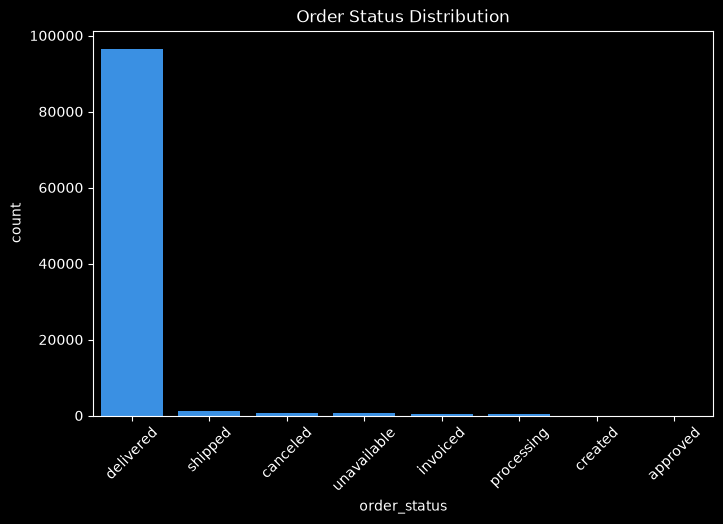

In [10]:
plt.style.use("dark_background")

plt.figure(figsize=(8,5))
sns.countplot(
    x="order_status",
    data=Orders,
    order=Orders['order_status'].value_counts().index,
    color="dodgerblue"
)
plt.title("Order Status Distribution", color="white")
plt.xticks(rotation=45, color="white")
plt.yticks(color="white")
plt.xlabel("order_status", color="white")
plt.ylabel("count", color="white")
plt.grid(False)
plt.show()




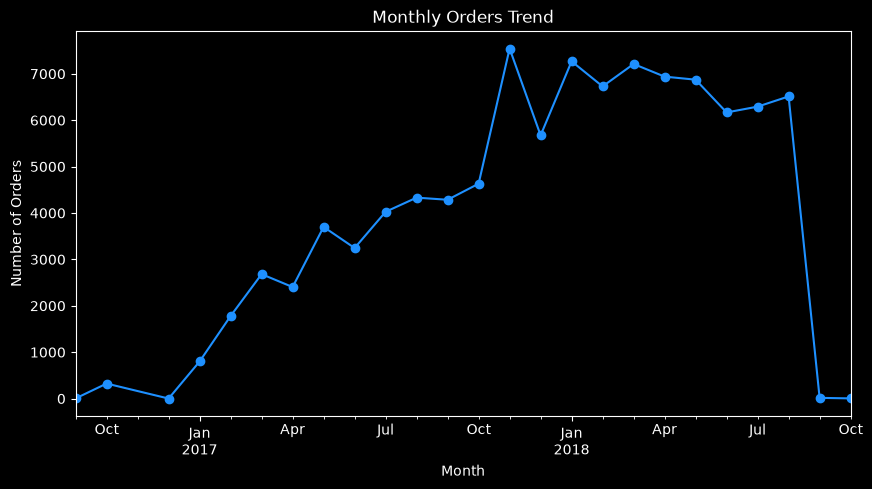

In [11]:
Orders['order_purchase_timestamp'] = pd.to_datetime(Orders['order_purchase_timestamp'])
Orders['month'] = Orders['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = Orders.groupby('month')['order_id'].count()

plt.style.use("dark_background")

monthly_orders.plot(kind='line', figsize=(10,5), marker='o', color="dodgerblue")
plt.title("Monthly Orders Trend", color="white")
plt.xlabel("Month", color="white")
plt.ylabel("Number of Orders", color="white")
plt.xticks(color="white")
plt.yticks(color="white")
plt.grid(False)
plt.show()



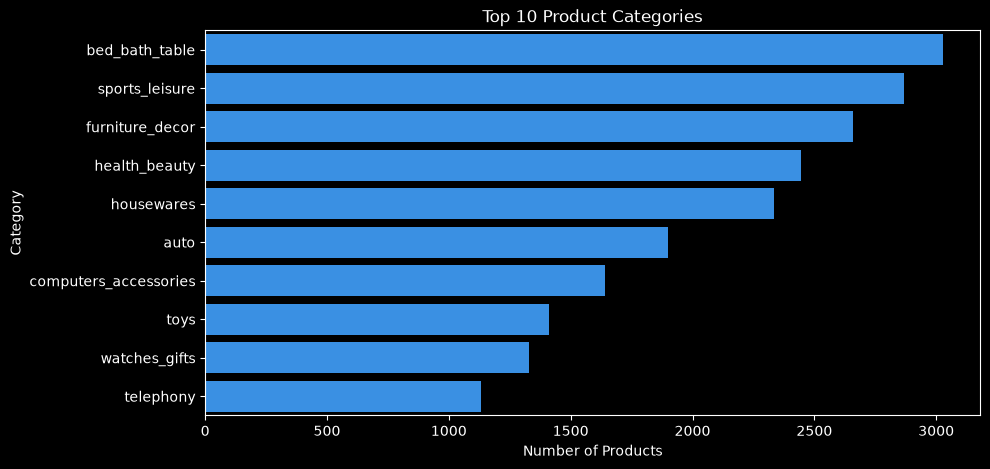

In [12]:
top_categories = Products['product_category_name'].value_counts().head(10)

top_categories_df = top_categories.reset_index()
top_categories_df.columns = ["product_category_name", "product_count"]

plt.style.use("dark_background")
plt.figure(figsize=(10,5))
sns.barplot(
    x="product_count",
    y="product_category_name",
    data=top_categories_df,
    color="dodgerblue"
)
plt.title("Top 10 Product Categories", color="white")
plt.xlabel("Number of Products", color="white")
plt.ylabel("Category", color="white")
plt.xticks(color="white")
plt.yticks(color="white")
plt.grid(False)
plt.show()




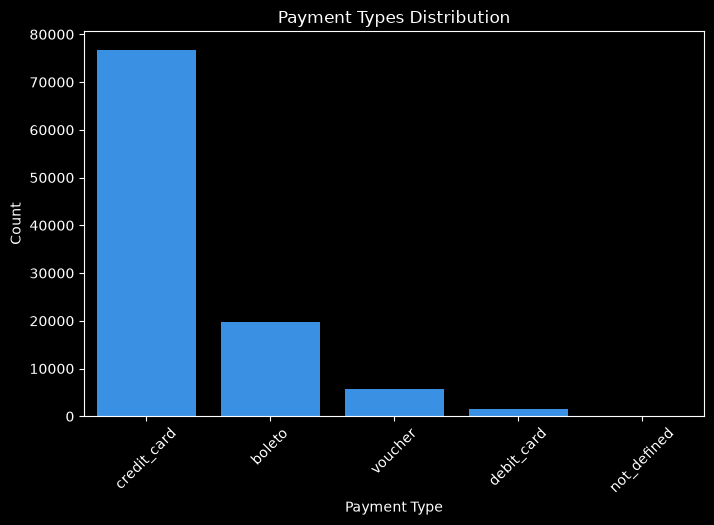

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("dark_background")

plt.figure(figsize=(8,5))
sns.countplot(
    x="payment_type",
    data=Payments,
    order=Payments['payment_type'].value_counts().index,
    color="dodgerblue"
)
plt.title("Payment Types Distribution", color="white")
plt.xlabel("Payment Type", color="white")
plt.ylabel("Count", color="white")
plt.xticks(rotation=45, color="white")
plt.yticks(color="white")
plt.grid(False)  # grid lines hata di
plt.show()

In [22]:
Orders.to_csv("02_Cleaned Dataset/orders_cleaned.csv", index=False)
Customers.to_csv("02_Cleaned Dataset/customers_cleaned.csv", index=False)
Products.to_csv("02_Cleaned Dataset/products_cleaned.csv", index=False)
Payments.to_csv("02_Cleaned Dataset/payments_cleaned.csv", index=False)
Reviews.to_csv("02_Cleaned Dataset/reviews_cleaned.csv", index=False)
Sellers.to_csv("02_Cleaned Dataset/sellers_cleaned.csv", index=False)
